In [ ]:
# Some code in this file was generated using AI

In [1]:
print("Hello world!")

Hello world!


In [21]:
import pandas, numpy, matplotlib, seaborn, scipy, networkx, plotly, requests, tqdm

print("All libraries imported successfully.")

All libraries imported successfully.


# Import


In [20]:
import json
import time
from typing import Dict, Iterable, List, Optional, Tuple

import requests
import pandas as pd
from tqdm import tqdm

# Task 2.1: Find Institution ID and Write to .jsonl


In [4]:
url = "https://api.openalex.org/institutions"
search_url = f"{url}?search=Florida+State+University&"

result = requests.get(search_url).json()
print(json.dumps(result, indent=4))

{
    "meta": {
        "count": 6,
        "db_response_time_ms": 56,
        "page": 1,
        "per_page": 25,
        "groups_count": null,
        "x_query": {
            "oql": "institutions where text has (Florida State University)",
            "oqo": {
                "get_rows": "institutions",
                "filter_rows": [
                    {
                        "column_id": "text.search",
                        "value": "Florida State University",
                        "operator": "has"
                    }
                ]
            },
            "url": "/institutions?filter=text.search:Florida State University"
        },
        "cost_usd": 0.001
    },
    "results": [
        {
            "id": "https://openalex.org/I103163165",
            "ror": "https://ror.org/05g3dte14",
            "display_name": "Florida State University",
            "relevance_score": 230946.66,
            "country_code": "US",
            "type": "education",
            

In [5]:
institution_id = result["results"][0]["id"]
print(institution_id)

https://openalex.org/I103163165


In [6]:
# Fetch works and save in .jsonl file
output_file = "backend/data/fsu_works_2021_2026.jsonl"

select = (
    "id",
    "doi",
    "display_name",
    "publication_year",
    "publication_date",
    "type",
    "cited_by_count",
    "authorships",
    "primary_location",
    "open_access",
    "concepts",
)

saved_count = 0

with open(output_file, "w", encoding="utf-8") as file:
    params = {
        "filter": f"institutions.id:{institution_id},publication_year:2021-2026",
        "select": ",".join(select),
        "per-page": 200,
        "cursor": "*",
    }

    with tqdm(desc="Fetching works", unit="works") as progress:
        while params["cursor"]:
            response = requests.get(
                "https://api.openalex.org/works",
                params=params,
            )
            response.raise_for_status()
            data = response.json()

            for work in data["results"]:
                file.write(json.dumps(work) + "\n")
                saved_count += 1

            progress.update(len(data["results"]))

            params["cursor"] = data["meta"].get("next_cursor")

print(f"Saved {saved_count} records to {output_file}")

Fetching works: 26603works [03:34, 124.16works/s]

Saved 26603 records to fsu_works_2021_2026.jsonl


# Task 2.2: Clean and Flattening


In [ ]:
# Turn .jsonl file into csv
import json
import pandas as pd

input_file = "backend/data/fsu_works_2021_2026.jsonl"


flattened_records = []

with open(input_file, "r", encoding="utf-8") as f:
    for line in f:
        work = json.loads(line)

        # Venue handling
        primary_loc = work.get("primary_location") or {}
        source = primary_loc.get("source") or {}
        venue = source.get("display_name")
        venue_id = source.get("id")

        # Authorships handling
        authorships = work.get("authorships") or []
        author_names = [
            auth.get("author", {}).get("display_name")
            for auth in authorships
            if auth.get("author", {}).get("display_name")
        ]
        authors = "; ".join(author_names) if author_names else None
        n_authors = len(author_names)

        # Concepts / Fields handling (sorted by score descending)
        concepts = work.get("concepts") or []
        concepts_sorted = sorted(
            concepts, key=lambda c: c.get("score", 0), reverse=True
        )

        all_fields = [
            c.get("display_name") for c in concepts_sorted if c.get("display_name")
        ]
        primary_field = all_fields[0] if all_fields else None
        fields_all = "; ".join(all_fields) if all_fields else None

        row = {
            "openalex_id": work.get("id"),
            "doi": work.get("doi"),
            "title": work.get("display_name"),
            "publication_year": work.get("publication_year"),
            "publication_date": work.get("publication_date"),
            "type": work.get("type"),
            "cited_by_count": work.get("cited_by_count"),
            "venue": venue,
            "venue_id": venue_id,
            "authors": authors,
            "n_authors": n_authors,
            "primary_field": primary_field,
            "fields_all": fields_all,
        }
        flattened_records.append(row)

# Task 2.3: Build Pandas DataFrame and Save to CSV


In [16]:
output_csv = "backend/data/fsu_works_2021_2026.csv"


df = pd.DataFrame(flattened_records)

# Save to CSV
df.to_csv(output_csv, index=False)

# Display shape and preview
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")
print(df.head())

Dataset Dimensions: 26603 rows, 13 columns

                        openalex_id  \
0  https://openalex.org/W2963002078   
1  https://openalex.org/W4401211033   
2  https://openalex.org/W3108936441   
3  https://openalex.org/W4387440676   
4  https://openalex.org/W3193988690   

                                             doi  \
0           https://doi.org/10.1093/ptep/ptac097   
1    https://doi.org/10.1103/physrevd.110.030001   
2  https://doi.org/10.1080/15548627.2020.1797280   
3       https://doi.org/10.1021/acs.jcim.3c01153   
4              https://doi.org/10.1063/5.0055522   

                                               title  publication_year  \
0                         Review of Particle Physics              2022   
1                         Review of Particle Physics              2024   
2  Guidelines for the use and interpretation of a...              2021   
3                                         AmberTools              2023   
4  Software for the frontiers of quant

# Task 3: Descriptive Statistics


In [17]:
# Load the csv
df = pd.read_csv("backend/data/fsu_works_2021_2026.csv")

# print each summary/statistic

year_counts = df["publication_year"].value_counts().sort_index()
print("--- Works by Publication Year ---")
print(year_counts)
print()

top_venues = df["venue"].value_counts().head(20)
print("--- Top 20 Venues ---")
print(top_venues)
print()

citation_stats = df["cited_by_count"].describe(percentiles=[0.25, 0.50, 0.75])[
    ["mean", "std", "min", "25%", "50%", "75%", "max"]
]
print("--- Citation Count Statistics ---")
print(citation_stats)
print()

field_counts = df["primary_field"].value_counts()
top_10_fields = pd.DataFrame(
    {
        "work_count": field_counts.head(10),
        "share_of_total": (field_counts.head(10) / len(df)) * 100,
    }
)
top_10_fields["share_of_total"] = top_10_fields["share_of_total"].map("{:.2f}%".format)

print("--- Top 10 Primary Fields ---")
print(top_10_fields)

--- Works by Publication Year ---
publication_year
2021    4215
2022    4100
2023    4275
2024    4389
2025    4932
2026    4692
Name: count, dtype: int64

--- Top 20 Venues ---
venue
SSRN Electronic Journal                                                                784
DOE Pacific Northwest National Laboratory (PNNL) Repository                            693
Zenodo (CERN European Organization for Nuclear Research)                               521
bioRxiv (Cold Spring Harbor Laboratory)                                                403
Cambridge University Press eBooks                                                      357
Journal of High Energy Physics                                                         216
Research Square                                                                        195
arXiv (Cornell University)                                                             192
Physical review. B./Physical review. B                                                 1

## What does the shape of these numbers say about research at FSU?

The highest number of publications is in materials science, business, and mathematics, which shows that these might be the most important research topics for the school. Furthermore, it seems that each year the publication counts are steadily increasing.


# Task 4: Static Charts in Matplotlib


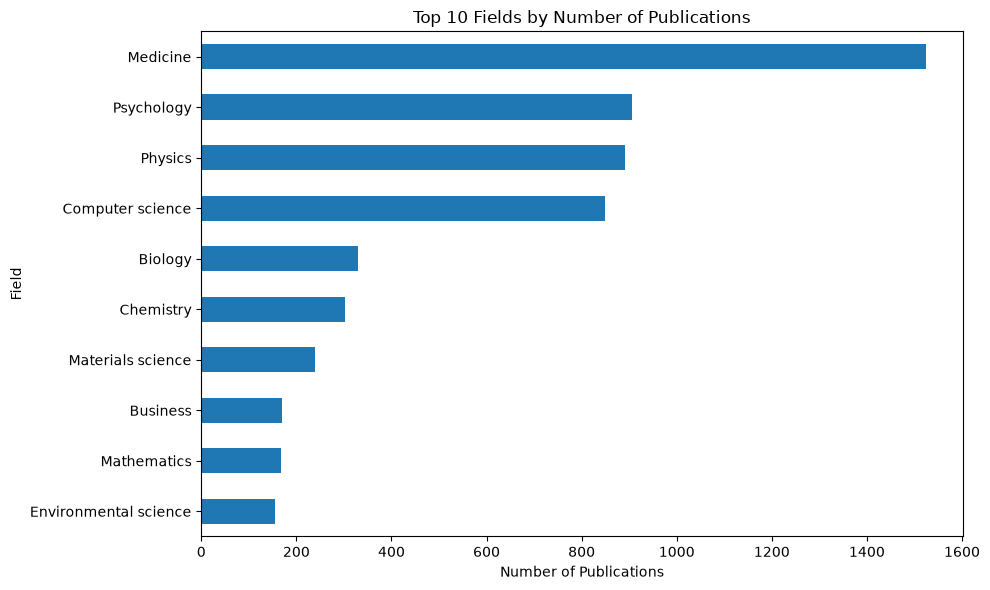

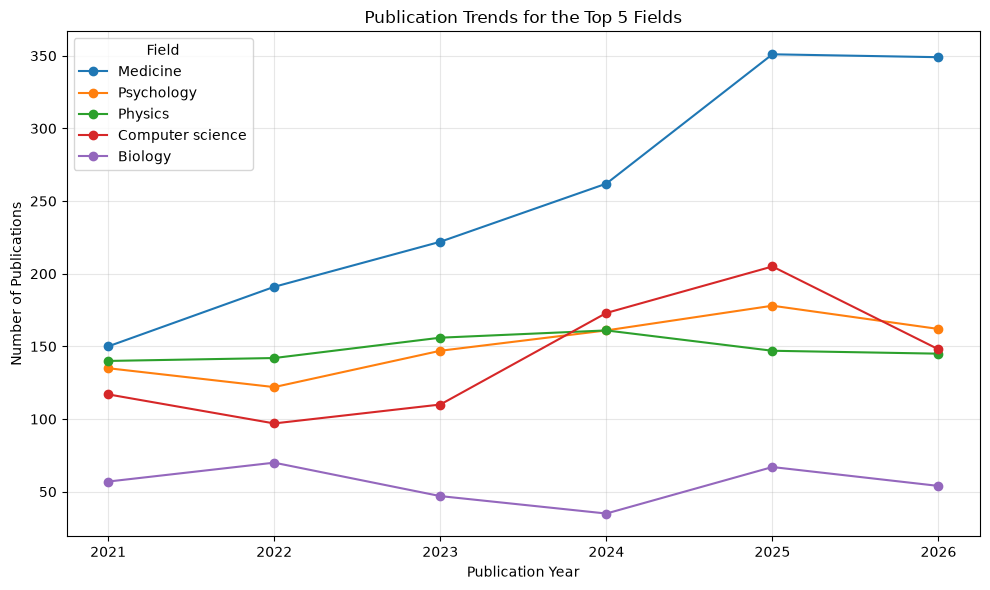

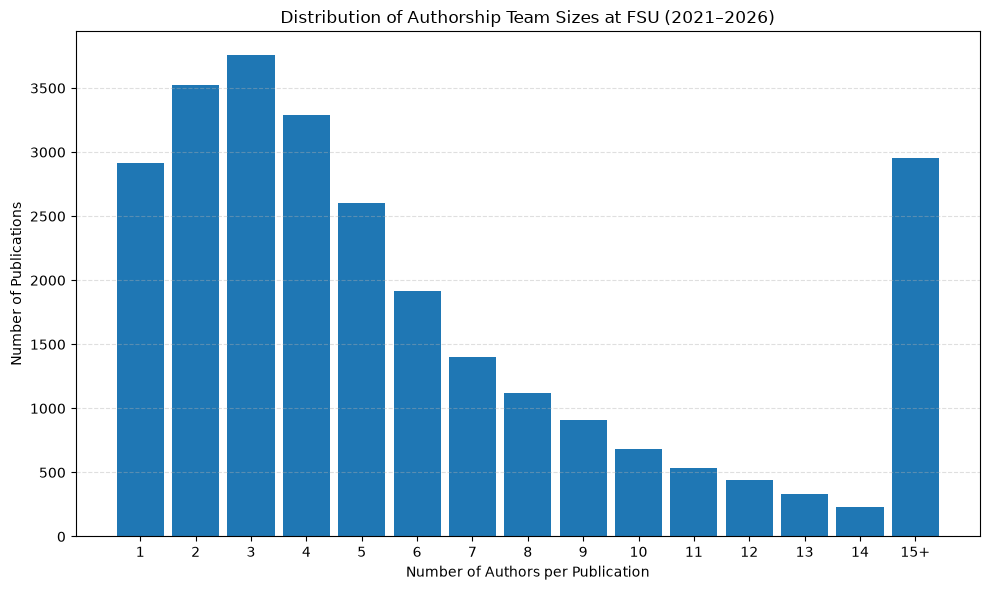

In [25]:
import matplotlib.pyplot as plt

## Chart 1: distribution of publications across fields

# Remove records without a primary field
plot_df = df.dropna(subset=["primary_field"]).copy()

# Top fields by publication count
field_counts = plot_df["primary_field"].value_counts()
top_10_fields = field_counts.head(10)

# Chart 1: Distribution of publications across fields
plt.figure(figsize=(10, 6))
top_10_fields.sort_values().plot(kind="barh")

plt.xlabel("Number of Publications")
plt.ylabel("Field")
plt.title("Top 10 Fields by Number of Publications")
plt.tight_layout()
plt.show()

## Chart 2: Field * year trend
top_5_fields = field_counts.head(5).index

field_year_counts = (
    plot_df[plot_df["primary_field"].isin(top_5_fields)]
    .groupby(["publication_year", "primary_field"])
    .size()
    .unstack(fill_value=0)
)

field_year_counts = field_year_counts.reindex(columns=top_5_fields, fill_value=0)

plt.figure(figsize=(10, 6))

for field in top_5_fields:
    plt.plot(
        field_year_counts.index,
        field_year_counts[field],
        marker="o",
        label=field,
    )

plt.xlabel("Publication Year")
plt.ylabel("Number of Publications")
plt.title("Publication Trends for the Top 5 Fields")
plt.legend(title="Field")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Chart 3: Distribution of Author Team Sizes
plt.figure(figsize=(10, 6))

# Filter valid positive author counts
authors_data = df["n_authors"].dropna()
max_display = 15

# Cap at 15+
capped_authors = authors_data.clip(upper=max_display)

counts, bins, patches = plt.hist(
    capped_authors,
    bins=range(1, max_display + 2),
    align="left",
    rwidth=0.85,
)

plt.xlabel("Number of Authors per Publication")
plt.ylabel("Number of Publications")
plt.title("Distribution of Authorship Team Sizes at FSU (2021–2026)")
plt.xticks(
    range(1, max_display + 1),
    [str(i) for i in range(1, max_display)] + [f"{max_display}+"],
)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Chart 1

Chart 1 shows FSU's research output is primarily medicine and psychology.
However, it hides interdisciplinary papers that involved multiple fields.

## Chart 2

Chart 2 shows FSU's top 5 fields have remained stable or expanded since 2021.
However, it hides the fact that the slight decline in 2026 might be that the year is not over yet.

## Chart 3

Chart 3 shows that most publications have around 3 authors.
However, it hides that maybe this varies a lot between fields.


# Task 5: Build and Visualize the Citation Network


In [23]:
# 5.1

df = pd.read_csv("backend/data/fsu_works_2021_2026.csv")

sample_size = 5000
sample_df = df.sample(n=sample_size)

edges = []

for _, row in tqdm.tqdm(
    sample_df.iterrows(), total=len(sample_df), desc="Fetching citations"
):
    id = str(row["openalex_id"]).rstrip("/").split("/")[-1]

    url = f"https://api.openalex.org/works/{id}"
    params = {"select": "id,referenced_works,related_works"}

    try:
        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()
        work = response.json()

        citing_id = work["id"].rstrip("/").split("/")[-1]

        for referenced_work in work.get("referenced_works", []):
            cited_id = referenced_work.rstrip("/").split("/")[-1]

            edges.append(
                {
                    "citing_paper_id": citing_id,
                    "cited_paper_id": cited_id,
                }
            )

    except requests.RequestException as error:
        print(f"Failed to fetch {id}: {error}")

    time.sleep(0.1)

# Citation edges
citation_links_all = pd.DataFrame(
    edges,
    columns=["citing_paper_id", "cited_paper_id"],
).drop_duplicates()

# Keep only edges whose endpoints are both FSU works
fsu_work_ids = set(
    df["openalex_id"].dropna().astype(str).str.rstrip("/").str.split("/").str[-1]
)

citation_links_within_fsu = citation_links_all[
    citation_links_all["citing_paper_id"].isin(fsu_work_ids)
    & citation_links_all["cited_paper_id"].isin(fsu_work_ids)
].copy()


citation_links_within_fsu.to_csv(
    "backend/data/paper_citation_links_within_fsu.csv", index=False
)

print(f"Saved {len(citation_links_within_fsu)} citation edges.")
citation_links_within_fsu.head()

Fetching citations:  60%|█████▉    | 2988/5000 [23:25<52:41:55, 94.29s/it]

Failed to fetch W4409087083: ('Connection aborted.', ConnectionResetError(54, 'Connection reset by peer'))


Fetching citations: 100%|██████████| 5000/5000 [44:56<00:00,  1.85it/s]    


Saved 3667 citation edges.


,citing_paper_id,cited_paper_id
264,W4400406761,W3136961763
589,W3176323679,W3157770066
758,W4289866219,W3126665462
761,W4289866219,W3133859695
763,W4289866219,W3136533732


In [31]:
# 5.2

import plotly.graph_objects as go

# Build the directed FSU citation network
graph = networkx.from_pandas_edgelist(
    citation_links_within_fsu,
    source="citing_paper_id",
    target="cited_paper_id",
    create_using=networkx.DiGraph,
)

# Fixed seed for reproducibility
positions = networkx.spring_layout(graph, seed=123)

# Edge coordinates
edge_x = []
edge_y = []

for source, target in graph.edges():
    x0, y0 = positions[source]
    x1, y1 = positions[target]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    mode="lines",
    line=dict(width=0.7, color="#888"),
    hoverinfo="none",
    name="Citations",
)

# Node coordinates and hover labels
node_ids = list(graph.nodes())
node_x = [positions[node][0] for node in node_ids]
node_y = [positions[node][1] for node in node_ids]

node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode="markers",
    marker=dict(
        size=9,
        color="#1f77b4",
        opacity=0.75,
        line=dict(width=0.5, color="white"),
    ),
    text=node_ids,
    hovertemplate="Paper ID: %{text}<extra></extra>",
    name="Papers",
)

fig = go.Figure(data=[edge_trace, node_trace])

fig.update_layout(
    title="FSU-Internal Citation Network",
    template="plotly_white",
    hovermode="closest",
    dragmode="zoom",
    showlegend=True,
    width=800,
    height=800,
    xaxis=dict(
        visible=False,
        showgrid=False,
        zeroline=False,
        showticklabels=False,
    ),
    yaxis=dict(
        visible=False,
        showgrid=False,
        zeroline=False,
        showticklabels=False,
    ),
)

fig.show(config={"scrollZoom": True})

# Task 7: Network Analysis


In [37]:
# Q1: Network Scale & Deduplication Metrics

print("Q1: How large is the citation network?")

num_nodes = graph.number_of_nodes()
num_edges_directed = graph.number_of_edges()

print(f"Total Unique Papers (Nodes): {num_nodes:,}")
print(f"Total Unique Directed Citation Links (Edges): {num_edges_directed:,}")
print(f"\n\n")


# Q2: Top 10 Most Cited Papers (Internal In-Degree vs Global)

print(f"Q2: What are the 10 most cited papers?")

# ensure ID normalization on works dataset
df_meta = df.copy()
df_meta["clean_id"] = (
    df_meta["openalex_id"].dropna().astype(str).str.rstrip("/").str.split("/").str[-1]
)

# eextract in-degree (number of times an FSU paper is cited by other sampled FSU papers)
in_deg_dict = dict(graph.in_degree())
network_nodes_df = pd.DataFrame(
    list(in_deg_dict.items()), columns=["clean_id", "fsu_in_degree"]
)

# merge metadata (Title, Year, Venue, Global cited_by_count)
merged_network_df = network_nodes_df.merge(
    df_meta[["clean_id", "title", "publication_year", "venue", "cited_by_count"]],
    on="clean_id",
    how="left",
).drop_duplicates(subset=["clean_id"])


# top 10 by Global cited_by_count among network papers
top_10_global = merged_network_df.sort_values(
    by=["cited_by_count", "fsu_in_degree"], ascending=[False, False]
).head(10)

print("Top 10 Most Cited Papers by OpenAlex Global Citations:")
table_global = top_10_global[
    ["title", "publication_year", "venue", "cited_by_count"]
].rename(
    columns={
        "title": "Title",
        "publication_year": "Year",
        "venue": "Venue",
        "cited_by_count": "Citation count",
    }
)
display(table_global)

Q1: How large is the citation network?
Total Unique Papers (Nodes): 3,851
Total Unique Directed Citation Links (Edges): 3,667



Q2: What are the 10 most cited papers?
Top 10 Most Cited Papers by OpenAlex Global Citations:


,Title,Year,Venue,Citation count
910,Review of Particle Physics,2022,Progress of Theoretical and Experimental Physics,6344
671,Review of Particle Physics,2024,Physical review. D/Physical review. D.,3544
869,AmberTools,2023,Journal of Chemical Information and Modeling,2145
442,Fly Cell Atlas: A single-nucleus transcriptomi...,2022,Science,899
1120,Increases in depression and anxiety symptoms i...,2021,Psychological Medicine,787
131,Polygenic prediction of educational attainment...,2022,Nature Genetics,715
22,Engagement in language learning: A systematic ...,2021,Language Teaching Research,658
2847,A somato-cognitive action network alternates w...,2023,Nature,649
232,Ultrahard magnetism from mixed-valence dilanth...,2022,Science,614
2440,Mesenchymal Stem Cell-Derived Exosomes: Applic...,2021,Cells,613
